In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from math import ceil
import os

In [2]:
data = pd.read_csv('data.csv', sep = ' ').fillna(0)

data = data.astype({'#Time': 'float64', 'SensorID': 'int', 'Value': 'float64'})

print(data.head(5))

   #Time  SensorID  Value
0    0.0         0    0.0
1    1.0         0    0.0
2    2.0         0    0.0
3    3.0         0    0.0
4    4.0         0    0.0


Number of sensors: 10
Sensor IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


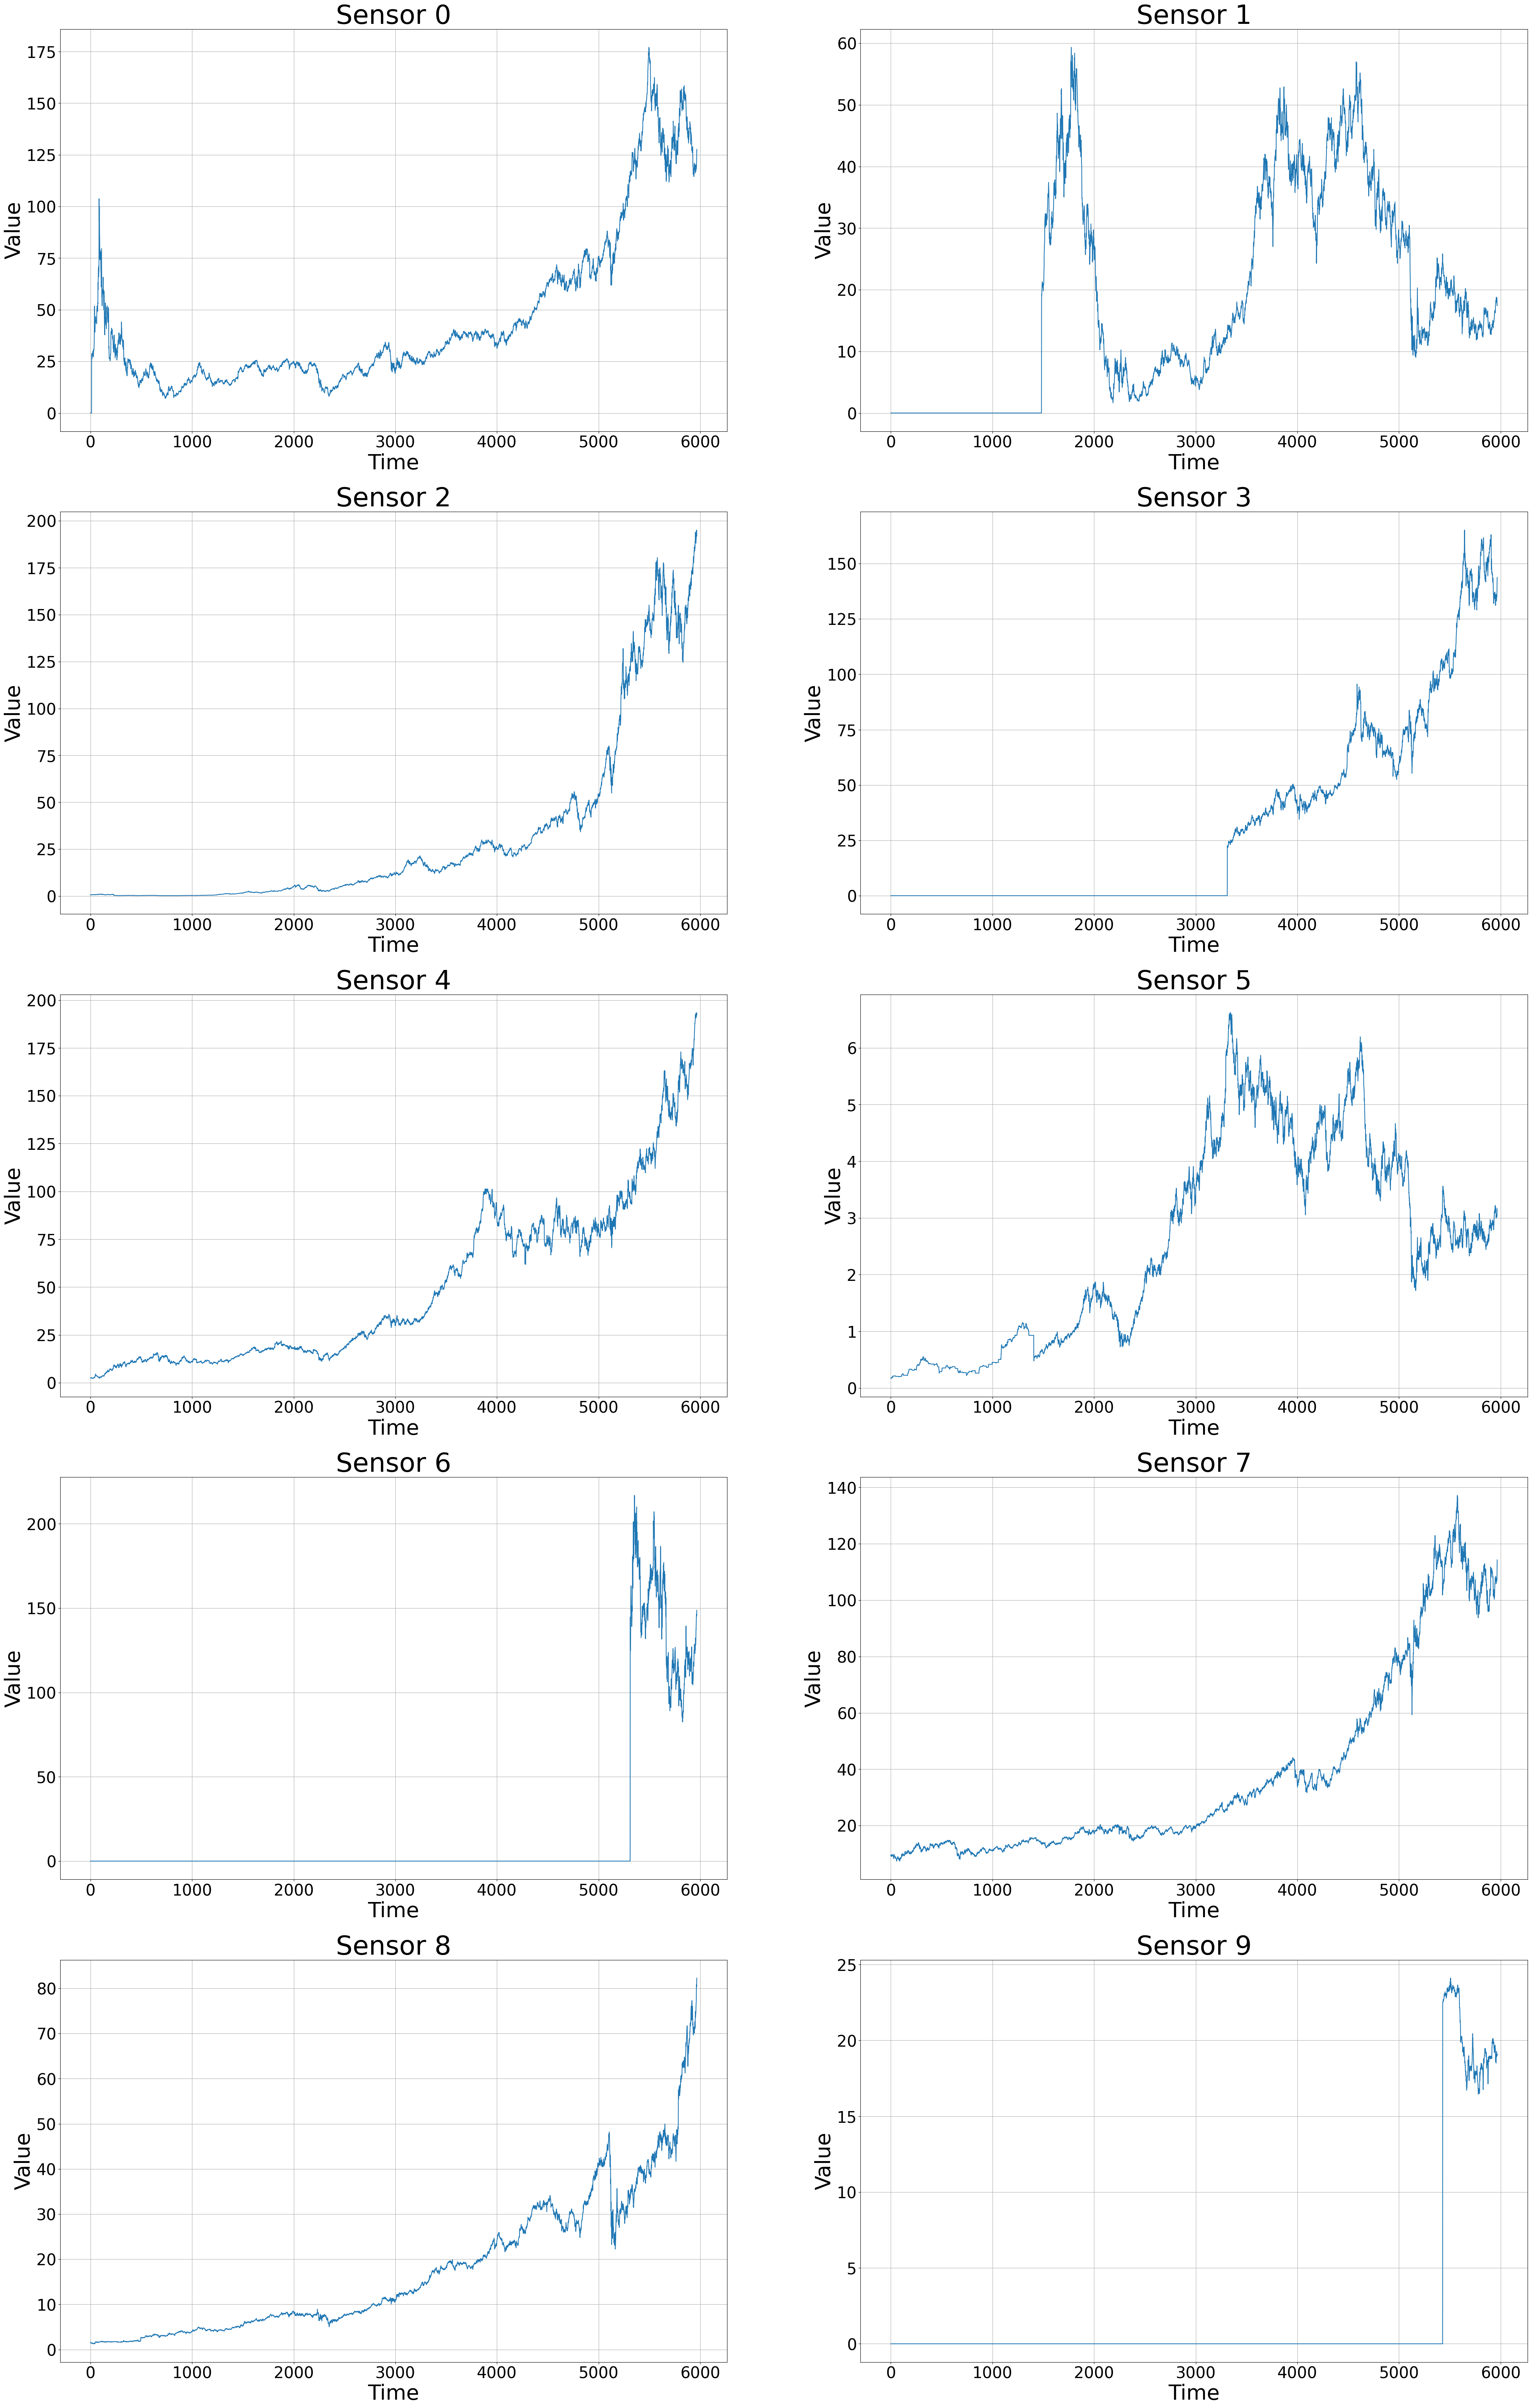

In [3]:
def plot_sensors_data(data):

  # Setting the paramters of the plots
  plt.rcParams.update({'xtick.labelsize': 30, 'ytick.labelsize' : 30, 'axes.labelsize' : 40, 'axes.titlesize': 50})

  # the number of the sensors
  sensors_num = len(data['SensorID'].unique())

  # the sensords id
  sensors_ids = list(data['SensorID'].unique())

  print(f"Number of sensors: {sensors_num}")
  print("Sensor IDs:", sensors_ids)

  # Define dimensions for plot
  f, axs = plt.subplots(ceil(sensors_num/2), 2,figsize=(50,80))
  axs = axs.flatten()

  # Loop through sensors ids
  for index, sensor_id in enumerate(sensors_ids):

    # filter the specific sensor`s data
    sensor_df = data[data['SensorID'] == sensor_id]

    axs[index].plot(sensor_df['#Time'], sensor_df['Value'])
    axs[index].set_title(f'Sensor {sensor_id}')
    axs[index].set_xlabel('Time')
    axs[index].set_ylabel('Value')
    axs[index].grid(True)


  plt.show()

# Call the plotting function to plot the data
plot_sensors_data(data)

In [4]:
def offline_phase(sliding_window, x_t, k=5, fraction=0.5, random_state=42):

    N = len(sliding_window)
    indices = np.arange(N)
    np.random.seed(random_state)
    np.random.shuffle(indices)
    split_point = int(fraction * N)
    S1 = sliding_window[indices[:split_point]]
    S2 = sliding_window[indices[split_point:]]

    nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(S1)
    distance, _ = nbrs.kneighbors([x_t])
    d_t = distance.sum()

    distances_S2 = []
    for s2_point in S2:
        distance, _ = nbrs.kneighbors([s2_point])
        distances_S2.append(distance.sum())

    return d_t, distances_S2

In [6]:

def detect_anomalies(data):
    # Setting the parameters of the plots
    plt.rcParams.update({'xtick.labelsize': 30, 'ytick.labelsize': 30, 'axes.labelsize': 30, 'axes.titlesize': 30})

    # the number of the sensors
    sensors_num = len(data['SensorID'].unique())

    # the sensors id
    sensors_ids = list(data['SensorID'].unique())

    # Define dimensions for plot
    f, axs = plt.subplots(sensors_num, 1, figsize=(50, 200))
    axs = axs.flatten()

    # Create directories to store anomaly files and plots
    os.makedirs('anomaly_results_GEM', exist_ok=True)
    os.makedirs('anomaly_plots_GEM', exist_ok=True)

    # Loop through sensors ids
    for index, sensor_id in enumerate(sensors_ids):
        # filter the specific sensor's data
        sensor_df = data[data['SensorID'] == sensor_id]

        g_t = 0
        h = 7
        alpha = 0.1
        anomalies = []

        W = 100
        t = W

        sensor_values = data.pivot(index='#Time', columns='SensorID', values='Value').fillna(0)

        num_iterations = len(sensor_values) - W

        for i in range(num_iterations):
            sliding_window = sensor_values.iloc[t-W:t].values
            x_t = sensor_values.iloc[t].values
            d_t, distances_S2 = offline_phase(sliding_window, x_t)
            p_t = sum(d > d_t for d in distances_S2) / len(distances_S2)
            if p_t == 0:
                p_t = 1/len(distances_S2)
            s_t = np.log(alpha / p_t)
            g_t = max(0, g_t + s_t)
            if g_t >= h:
                anomalies.append(sensor_values.index[t])
                g_t = 0
            t += 1

        # Plot the results
        axs[index].plot(sensor_df['#Time'], sensor_df['Value'], color='blue', alpha=0.5, linewidth=2)
        if anomalies:
            axs[index].scatter(anomalies, sensor_df.loc[sensor_df['#Time'].isin(anomalies), 'Value'].values, color='red', label='Anomalies', s=20)
        axs[index].set_title(f'Anomalies for sensor {sensor_id}')
        axs[index].set_xlabel('Time')
        axs[index].set_ylabel('Value')
        
        axs[index].grid(True, which='major', linestyle='-', linewidth='0.5', color='gray')
        axs[index].grid(True, which='minor', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
        axs[index].minorticks_on()

        # Save the plot as PNG
        plt.figure(figsize=(50, 20))
        plt.plot(sensor_df['#Time'], sensor_df['Value'], color='blue', alpha=0.5, linewidth=2)
        if anomalies:
            plt.scatter(anomalies, sensor_df.loc[sensor_df['#Time'].isin(anomalies), 'Value'].values, color='red', label='Anomalies', s=20)
        plt.title(f'Anomalies for sensor {sensor_id}')
        plt.xlabel('Time')
        plt.ylabel('Value')
        
        plt.grid(True, which='major', linestyle='-', linewidth='0.5', color='gray')
        plt.grid(True, which='minor', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
        plt.minorticks_on()

        plot_file = os.path.join('anomaly_plots_GEM', f'sensor_{sensor_id}_plot.png')
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        plt.close()

        # Save anomalies to a text file
        anomaly_file = os.path.join('anomaly_results_GEM', f'sensor_{sensor_id}_anomalies.txt')
        with open(anomaly_file, 'w') as f:
            f.write(f"Anomalies for Sensor {sensor_id}:\n")
            for anomaly_time in anomalies:
                anomaly_value = sensor_df.loc[sensor_df['#Time'] == anomaly_time, 'Value'].values[0]
                f.write(f"Time: {anomaly_time}, Value: {anomaly_value}\n")

    plt.show()
    print("Anomaly detection completed. Results saved in 'anomaly_results' and 'anomaly_plots' directories.")

# Plotting the anomalies in all of the sensors data
detect_anomalies(data)



Anomaly detection completed. Results saved in 'anomaly_results' and 'anomaly_plots' directories.
